In [15]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from spaces.SPD import SymmetricPositiveDefinite
from algorithms.ProxSpliting import Prox


space = SymmetricPositiveDefinite(dimension=3, metric= "airm") 
S = space.sample(n_samples=20, seed=0, dtype=np.float64)
prox = Prox(space=space)

fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                            tau=0.1, 
                            lam=0.5,  
                            p=2.0,
                            tol=1e-16, max_outer_iter=50)

100%|██████████| 50/50 [00:01<00:00, 42.55it/s]


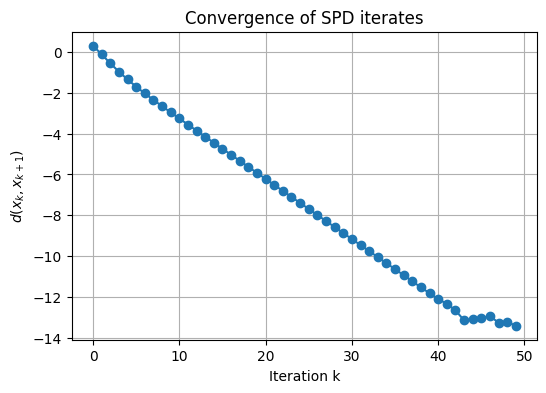

In [16]:
import matplotlib.pyplot as plt
#eps = 1e-16
distances = [np.log10(space.dist(x_seq[i], x_seq[i+1])) for i in range(len(x_seq)-1)]
#distances = [max(d, eps) for d in distances] 


plt.figure(figsize=(6,4))
plt.plot(distances, marker='o')
plt.xlabel('Iteration k')
plt.ylabel(r'$d(x_{k} , x_{k+1})$')
plt.title('Convergence of SPD iterates')
plt.grid(True)
plt.show()
